In [1]:
from data_utils import filter_tensors, extract_TensorDataset, extract_interior, extract_boundary, replace_labels, get_circle, get_grid, subsample, prepare_dataset
from generate import generate_AdvectionReactionDiffusion, generate_AdvectionReactionDiffusion_unlabeled, generate_AllenCahn, generate_AllenCahn_unlabeled, help_circle, help_circle_bc, help_ic, help_rectangle, help_rectangle_bc
from advection_reaction_diffusion import make_source, make_velocity

In [2]:
help_rectangle()
help_rectangle_bc()
help_ic()


"x_range": Tuple[float, float],
"y_range": Tuple[float, float],
"dx": float,
"dy": float
    

"left": Tuple[str, float],
"top": Tuple[str, float],
"right": Tuple[str, float],
"bottom": Tuple[str, float]
    

"gaussian": bool,
"periodic_circles": bool,
"periodic_valleys": bool,
"periodic_stripes": bool,
"periodic_grid": bool,
"uniform_noise": bool,
"u0": np.ndarray,
"centers": List[Tuple[float, float]], "amps": List[float], "sigmas": List[float],
"A": float, "Ax": float, "Ay": float,
"B": float, "Bx": float, "By": float,
"Cx": float, "Cy": float,
"D": float,
"min_noise": float, "max_noise": float
    


In [3]:
help_circle()
help_circle_bc()


"cell_size": float,
"radius": float
    

"mode": str,
"value": float
    


In [4]:
velocity = make_velocity(field="rotation_expansion", alpha_mode="const", alpha=10.0, beta_mode="const", beta=0.0)
source = make_source(mode="temporary", amp=0, sigma=1, center=(0, 0), period=1)
def implicit_source(x, y, t, u):
    return 0.0
implicit_source = make_source(mode="logistic", A=1, B=10)
rectangle = {
    "x_range": (-1, 1),
    "y_range": (-1, 1),
    "dx": 0.02,
    "dy": 0.02
}
rectangle_bc = {
    "left": ("Neumann", 0.0),
    "top": ("Neumann", 0.0),
    "right":("Neumann", 0.0),
    "bottom": ("Neumann", 0.0)
}
circle = {
    "cell_size": 0.02,
    "radius": 1
}
circle_bc = {
    "mode": "Neumann",
    "value": 0.0
}
ic = {
    "gaussian": True,
    "periodic_circles": False,
    "periodic_valleys": False,
    "periodic_stripes": False,
    "periodic_grid": False,
    "uniform_noise": False,
    "u0": 0.0,
    "centers": [(0.0, 0.0), (0.5, 0.5)], "amps": [6, 5], "sigmas": [0.2, 0.5],
    "A": 0, "Ax": 0, "Ay": 0,
    "B": 0, "Bx": 0, "By": 0,
    "Cx": 0, "Cy": 0,
    "D": 0,
    "min_noise": 0, "max_noise": 0
}
dataset = generate_AdvectionReactionDiffusion(velocity=velocity, source=source, implicit_source=implicit_source, shape="circle", spatial_region=circle, bc=circle_bc, ic=ic, t0=0, tN=2.0, dt=0.2, n_snapshots=10, snapshot_start=0.0, diffusion_coeff=0.1)

In [5]:
import torch
from torch.utils.data import TensorDataset
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import numpy as np
from generate import X, U
def plot_points(
        dataset: str|TensorDataset|list,
        labels_idx: int|list = U,
        points_idx: int|list = X,
        labels_name: str|list = "u",
        save: bool = False,
        dst_file: str = "points.png",
        show: bool = True,
        cmap: str|list = "inferno",
        title: str = "",
        subtitles: list = [],
        single_row: bool = False,
        figsize: tuple = (5, 5),
        vmin: float|list = None,
        vmax: float|list = None
    ) -> None:
    """
    Plot the dataset(s) points, colored according to the label values.

    Parameters
    ----------
    dataset : str|TensorDataset|list
        The dataset filepath/TensorDataset object or TensorDataset list.
    labels_idx : int|list,
        Labels column index in the dataset(s).
    points_idx : int|list
        Spatial coordinates column index in the dataset(s).
    labels_name : str|list,
    save : bool
        If True, the plot is saved.
    dst_file : str
        Filepath where to save the plot.
    show : bool
        If True, the plot is showed.
    cmap : str|list
    title : str
    subtitles : list
    single_row : bool
    figsize : tuple
    vmin : float
    vmax : float
    
    Returns
    -------
    None
    """
    if type(dataset) is str:
        datasets = [torch.load(dataset, weights_only=False)]
    elif type(dataset) is list:
        datasets = []
        for ds in dataset:
            if type(ds) is str:
                datasets.append(torch.load(ds, weights_only=False))
            else:
                datasets.append(ds)
    else:
        datasets = [dataset]

    if type(labels_idx) is int:
        labels_idx = [labels_idx for _ in datasets]
    if type(labels_name) is str:
        names = [labels_name for _ in datasets]
    else:
        names = labels_name
    if type(points_idx) is int:
        points_idx = [points_idx for _ in datasets]
    pointss = [dataset.tensors[i] for dataset, i in zip(datasets, points_idx)]
    labelss = []
    if type(cmap) is str:
        cmaps = []
        for dataset, i in zip(datasets, labels_idx):
            if i > -1:
                labelss.append(dataset.tensors[i])
                cmaps.append(cmap)
            else:
                labelss.append(torch.zeros_like(dataset.tensors[U]))
                cmaps.append("grey")
    else:
        cmaps = cmap
        for dataset, i in zip(datasets, labels_idx):
            labelss.append(dataset.tensors[i])

    if vmin is None or type(vmin) is float:
        vmins = [vmin for _ in datasets]
        vmaxs = [vmax for _ in datasets]
    else:
        vmins = vmin
        vmaxs = vmax

    font = {'size': 10}
    matplotlib.rc('font', **font)
    fig = plt.figure(figsize=figsize)

    if len(labels_idx) <= 4 or single_row:
        gs = GridSpec(1, len(labels_idx), figure=fig)
        axes = [fig.add_subplot(gs[0, i]) for i in range(len(labels_idx))]
    elif len(labels_idx) <= 8:
        ncols = int(np.ceil(len(labels_idx)/2))
        gs = GridSpec(2, ncols, figure=fig)
        axes = []
        for i in range(ncols):
            axes.append(fig.add_subplot(gs[0, i]))
            axes.append(fig.add_subplot(gs[1, i]))
    elif len(labels_idx) <= 16:
        ncols = int(np.ceil(len(labels_idx)/3))
        gs = GridSpec(3, ncols, figure=fig)
        axes = []
        for i in range(ncols):
            axes.append(fig.add_subplot(gs[0, i]))
            axes.append(fig.add_subplot(gs[1, i]))
            axes.append(fig.add_subplot(gs[2, i]))
    elif len(labels_idx) <= 24:
        ncols = int(np.ceil(len(labels_idx)/4))-1
        gs = GridSpec(5, ncols, figure=fig)
        axes = []
        for i in range(ncols):
            axes.append(fig.add_subplot(gs[0, i]))
            axes.append(fig.add_subplot(gs[1, i]))
            axes.append(fig.add_subplot(gs[2, i]))
            axes.append(fig.add_subplot(gs[3, i]))
            axes.append(fig.add_subplot(gs[4, i]))
    else:
        raise ValueError("Too many plots.")
    
    if subtitles == []:
        subtitles = ["" for _ in axes]
    for ax, points, labels, name, cmap, vmin, vmax, subtitle in zip(axes, pointss, labelss, names, cmaps, vmins, vmaxs, subtitles):
        if vmin is not None and vmax is not None:
            scatter = ax.scatter(points[:, 0], points[:, 1], s=1, alpha=1, c=labels.flatten(), cmap=cmap, vmin=vmin, vmax=vmax)
        else:
            scatter = ax.scatter(points[:, 0], points[:, 1], s=1, alpha=1, c=labels.flatten(), cmap=cmap)

        #if ax == axes[-1]:
        #    cbar = fig.colorbar(scatter, ax=ax)
        #    cbar.set_label(name)
        #ax.set_xlabel('x')
        #ax.set_ylabel('y')
        if subtitle != "":
            ax.set_title(subtitle)
        
        ax.set_xticks([-1, 0, 1])
        ax.set_yticks([-1, 0, 1])
        ax.plot()
    fig.subplots_adjust(right=0.85, wspace=0.5, hspace=0.5) 
    cbar_ax = fig.add_axes([0.88, 0.15, 0.01, 0.7]) # [left, bottom, width, height]
    fig.colorbar(scatter, cax=cbar_ax, label=names[-1])
    #cbar = fig.colorbar(scatter, ax=axes, fraction=0.046, pad=0.04)
    #cbar.set_label(names[-1])
    
    #plt.gca().set_aspect('equal', adjustable='box')
    fig.suptitle(title)
    #if caption != "":
    #    fig.text(
    #        0.01, 0.5, caption, 
    #        ha='left', va='center', fontsize=10, 
    #        linespacing=1.5
    #    )
    #    # rect=[left, bottom, right, top]
    #    plt.tight_layout(rect=[0.2, 0, 1, 1])
    #else:
    #    fig.tight_layout()
    #plt.tight_layout()
    if save:
        plt.savefig(fname=dst_file, bbox_inches='tight', dpi=300)
    if show:
        plt.show()
    else:
        plt.close()

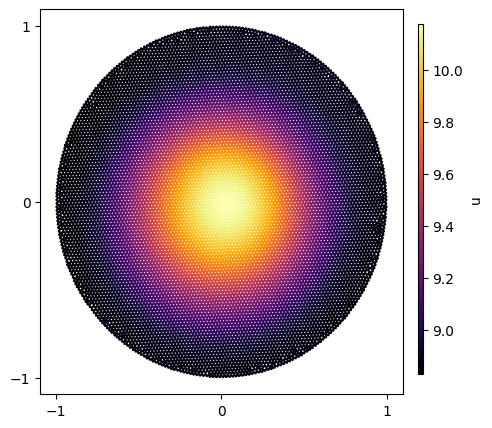

In [6]:
plot_points(dataset=dataset.datasets[4])

In [ ]:
bd = extract_boundary(dataset=dataset, shape="circle", cell_size=0.02, center=[0,0], radius=1.0, t=0)

plot_points(dataset=bd)

In [4]:
dataset.datasets[1].tensors

(tensor([[-0.9900, -0.9900,  0.2000],
         [-0.9700, -0.9900,  0.2000],
         [-0.9500, -0.9900,  0.2000],
         ...,
         [ 0.9500,  0.9900,  0.2000],
         [ 0.9700,  0.9900,  0.2000],
         [ 0.9900,  0.9900,  0.2000]], dtype=torch.float64),
 tensor([0.3398, 0.3400, 0.3404,  ..., 1.5815, 1.5815, 1.5815],
        dtype=torch.float64),
 tensor([[ 4.7260e-03,  8.4340e-03,  1.6957e+00],
         [ 1.4187e-02,  8.4504e-03,  1.6962e+00],
         [ 2.3658e-02,  8.4831e-03,  1.6976e+00],
         ...,
         [ 4.7905e-03,  3.5222e-03, -2.4083e+00],
         [ 9.4654e-04,  3.1970e-03, -2.0354e+00],
         [-1.7796e-04,  3.0220e-03, -1.6609e+00]], dtype=torch.float64),
 tensor([[[ 2.3693e+01,  4.0973e-04,  1.2703e-02],
          [ 4.0973e-04,  4.1600e+01,  3.1244e-02],
          [ 1.2703e-02,  3.1244e-02,  0.0000e+00]],
 
         [[ 1.4800e-01,  1.2255e-03,  4.7883e-02],
          [ 1.2255e-03,  4.1681e+01,  2.9952e-02],
          [ 4.7883e-02,  2.9952e-02,  0.0000e+

In [16]:
X = get_grid(xmin_list=[-1, -1], xmax_list=[1, 1], dx_list=[0.01, 0.01])
#X = get_circle(radius=1, dx_list=[0.01, 0.01])

In [10]:
X

tensor([[-1.0000e+00,  8.9407e-10],
        [-9.8000e-01, -1.8000e-01],
        [-9.8000e-01, -1.6000e-01],
        ...,
        [ 9.8000e-01,  1.6000e-01],
        [ 9.8000e-01,  1.8000e-01],
        [ 1.0000e+00,  8.9407e-10]])

In [17]:
dataset = generate_AllenCahn(lam=0.1, xi=[0.1, 0.2, 3, -2, 10], X=X)

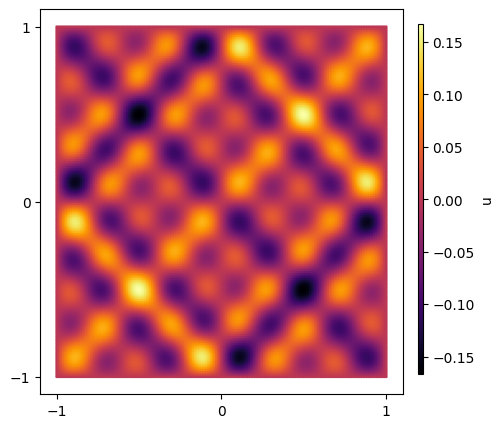

In [18]:
plot_points(dataset=dataset, show=True)